In [2]:
import pandas as pd

In [3]:
df_countries=pd.read_csv("../../data/reduced_data/population/population-countries.csv")

In [4]:
df_groups=pd.read_csv("../../data/reduced_data/population/population-by-group.csv")

In [5]:
pd.options.display.float_format = '{:,.0f}'.format ##Fancy formatting

In [6]:
df_countries.sort_values('2024',ascending=False)[['Country Name','2024']].head(10)

,Country Name,2024
88,India,"1,450,935,791"
35,China,"1,408,975,000"
201,United States,"340,110,988"
86,Indonesia,"283,487,931"
148,Pakistan,"251,269,164"
140,Nigeria,"232,679,478"
26,Brazil,"211,998,573"
17,Bangladesh,"173,562,364"
163,Russian Federation,"143,533,851"
60,Ethiopia,"132,059,767"


In [8]:
import plotly.express as px

In [9]:
fig = px.choropleth(
    df_countries,
    locations="Country Code",     
    color="2024",
    hover_name="Country Name",
    color_continuous_scale=[
        "blue",
        "green",
        "yellow",
        "red"
    ],
     hover_data={
                '2024': ':,',    
     }
)

In [10]:
fig.show()

## The map isnt helpful most countries have the same color

In [11]:
bins = [0, 1_000_000, 5_000_000, 10_000_000, 30_000_000 ,50_000_000 ,100_000_000 ,300_000_000 ,2_000_000_000]
labels = ['Miniscule <1m', 'Very Low <5m', 'Low <10m', 'Average <30m', 'Above Average <50m','High <100m','Very High <300m','Extremely High 300m>']
df_countries['population_category'] = pd.cut(df_countries['2024'], bins=bins, labels=labels, include_lowest=True)


In [12]:
fig = px.choropleth(df_countries,
                    title='Worl Population',
                    locations='Country Code',
                    color='population_category',                     # use binned column
                    color_discrete_sequence=px.colors.qualitative.Set3,  # nice palette
                    hover_name='Country Name',
                    hover_data={'2024': ':,'})  

fig.update_geos(
    bgcolor="#1399d7",  # or any color you want
    showland=True,
    landcolor="#A4CDE3",     # optional: change land color too
    showcountries=True,
    countrycolor='white'
)

fig.update_layout(
    paper_bgcolor="#BCAC90",width=1200, height=600,
    title={
        'text': "World population (2024)",  
        'y': 0.95,
        'x': 0.45,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {
            'size': 24,
            'color': 'Darkred',
            'weight': 'bold'
        }
    }
)

##  World population over time

In [13]:
df_subset_countries = df_countries[['Country Name'] + list(df_countries.loc[:, '1960':'2024'].columns)]
df_subset_groups = df_groups[['Country Name'] + list(df_groups.loc[:, '1960':'2024'].columns)]

In [14]:
df_subset_countries.head(10)

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,"54,922","55,578","56,320","57,002","57,619","58,190","58,694","58,990","59,069",...,"107,906","108,727","108,735","108,908","109,203","108,587","107,700","107,310","107,359","107,995"
1,Afghanistan,"9,035,043","9,214,083","9,404,406","9,604,487","9,814,318","10,036,008","10,266,395","10,505,959","10,756,922",...,"33,831,764","34,700,612","35,688,935","36,743,039","37,856,121","39,068,979","40,000,412","40,578,842","41,454,761","42,647,492"
2,Angola,"5,231,654","5,301,583","5,354,310","5,408,320","5,464,187","5,521,981","5,581,386","5,641,807","5,702,699",...,"28,157,798","29,183,070","30,234,839","31,297,155","32,375,632","33,451,132","34,532,429","35,635,029","36,749,906","37,885,849"
3,Albania,"1,608,800","1,659,800","1,711,319","1,762,621","1,814,135","1,864,791","1,914,573","1,965,598","2,022,272",...,"2,731,293","2,689,469","2,648,285","2,607,733","2,567,801","2,528,480","2,489,762","2,451,636","2,414,095","2,377,128"
4,Andorra,"9,510","10,283","11,086","11,915","12,764","13,634","14,626","15,837","17,176",...,"72,174","72,181","73,763","75,162","76,474","77,380","78,364","79,705","80,856","81,938"
5,United Arab Emirates,"131,334","137,989","144,946","152,211","159,692","167,103","173,976","179,700","199,416",...,"8,505,237","8,935,095","9,223,225","9,346,701","9,445,785","9,401,038","9,575,152","10,074,977","10,483,751","10,986,400"
6,Argentina,"20,386,045","20,726,276","21,072,538","21,421,705","21,769,453","22,112,629","22,453,893","22,799,059","23,150,583",...,"43,477,012","43,900,313","44,288,894","44,654,882","44,973,465","45,191,965","45,312,281","45,407,904","45,538,401","45,696,159"
7,Armenia,"1,863,705","1,927,484","1,991,689","2,056,023","2,120,135","2,183,635","2,246,159","2,307,492","2,367,319",...,"3,004,600","2,992,300","2,979,400","2,969,000","2,962,500","2,961,500","2,962,300","2,969,200","2,964,300","3,033,500"
8,American Samoa,"20,133","20,666","21,298","21,966","22,673","23,406","24,136","24,863","25,614",...,"52,878","52,245","51,586","50,908","50,209","49,761","49,225","48,342","47,521","46,765"
9,Antigua and Barbuda,"55,603","56,540","57,336","58,138","59,020","59,970","60,900","61,837","62,809",...,"89,409","89,969","90,468","90,926","91,364","91,846","92,349","92,840","93,316","93,772"


In [15]:
df_world=df_subset_groups[df_subset_groups['Country Name']=='World']
df_morocco = df_subset_countries[df_subset_countries['Country Name']=='Morocco']

In [16]:
df_world

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
48,World,"3,021,512,598","3,062,768,116","3,117,372,187","3,184,063,049","3,251,253,200","3,318,997,522","3,389,087,189","3,459,015,356","3,530,703,561",...,"7,441,677,465","7,528,879,985","7,614,523,410","7,697,233,736","7,778,008,621","7,854,748,424","7,920,514,854","7,989,545,217","8,064,057,930","8,141,808,945"


In [17]:
df_morocco

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
118,Morocco,"11,624,933","11,931,085","12,253,092","12,577,502","12,898,886","13,239,171","13,597,065","13,968,175","14,347,899",...,"34,607,588","35,023,457","35,446,392","35,839,760","36,210,898","36,584,208","36,954,442","37,329,064","37,712,505","38,081,173"


In [18]:
df_world

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
48,World,"3,021,512,598","3,062,768,116","3,117,372,187","3,184,063,049","3,251,253,200","3,318,997,522","3,389,087,189","3,459,015,356","3,530,703,561",...,"7,441,677,465","7,528,879,985","7,614,523,410","7,697,233,736","7,778,008,621","7,854,748,424","7,920,514,854","7,989,545,217","8,064,057,930","8,141,808,945"


In [19]:

df_morocco_years = df_morocco.set_index('Country Name').T

df_morocco_years.columns =['Population']
df_morocco_years['Year']=df_morocco_years.index
df_morocco_years=df_morocco_years[['Year','Population']]
df_morocco_years = df_morocco_years.reset_index(drop=True)


df_morocco_years.head(10)

,Year,Population
0,1960,"11,624,933"
1,1961,"11,931,085"
2,1962,"12,253,092"
3,1963,"12,577,502"
4,1964,"12,898,886"
5,1965,"13,239,171"
6,1966,"13,597,065"
7,1967,"13,968,175"
8,1968,"14,347,899"
9,1969,"14,734,255"


In [20]:

df_world_years = df_world.set_index('Country Name').T

df_world_years.columns =['Global Population']
df_world_years['Year']=df_world_years.index
df_world_years=df_world_years[['Year','Global Population']]
df_world_years = df_world_years.reset_index(drop=True)


df_world_years

,Year,Global Population
0,1960,"3,021,512,598"
1,1961,"3,062,768,116"
2,1962,"3,117,372,187"
3,1963,"3,184,063,049"
4,1964,"3,251,253,200"
...,...,...
60,2020,"7,854,748,424"
61,2021,"7,920,514,854"
62,2022,"7,989,545,217"
63,2023,"8,064,057,930"


In [21]:
df_world_years.info() ## Year should be int to work with

<class 'pandas.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               65 non-null     str    
 1   Global Population  65 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.1 KB


In [22]:
df_world_years['Year'] = df_world_years['Year'].astype(int)
df_morocco_years['Year'] = df_morocco_years['Year'].astype(int)


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

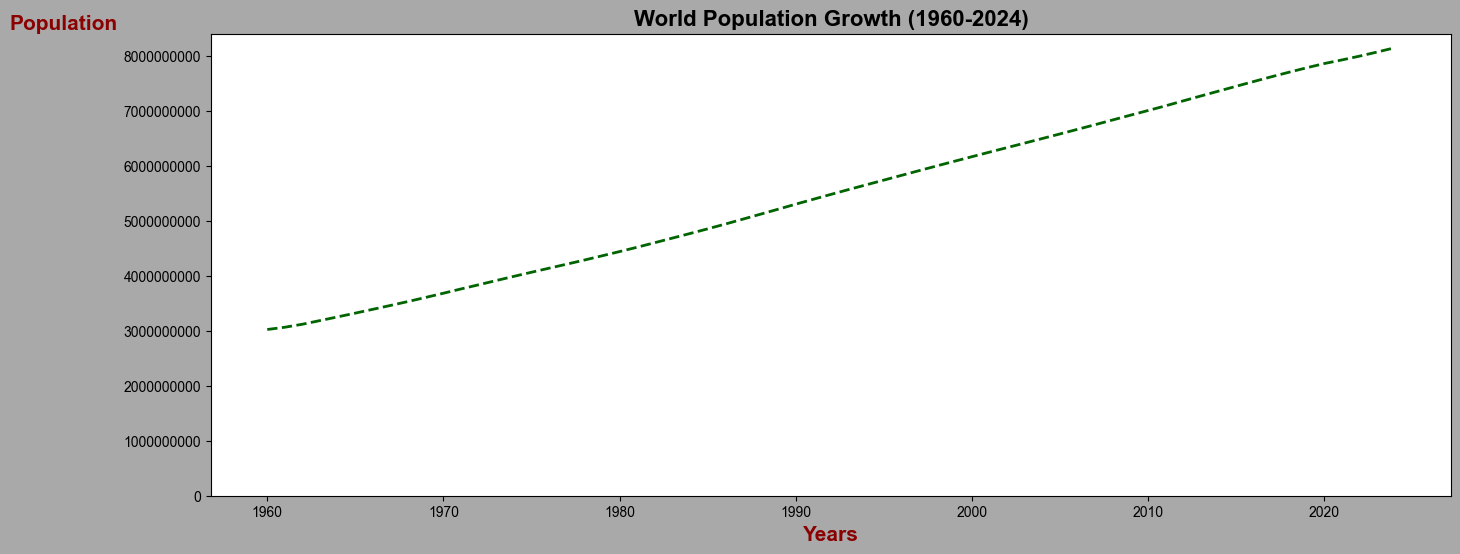

In [24]:
plt.figure(figsize=(16, 6))

sns.lineplot(data=df_world_years, x='Year', y='Global Population', linewidth=2, color='DarkGreen',  linestyle='--')
plt.title('World Population Growth (1960-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Years', fontsize=15, color='DarkRed', fontweight='bold')


plt.gcf().set_facecolor('Darkgray')
sns.set_style('darkgrid') 

plt.ylabel('Population',fontweight='bold', fontsize=15, color='DarkRed', rotation=0, loc='top')
plt.ylim(bottom=0)

plt.ticklabel_format(style='plain', axis='y')  

plt.show()

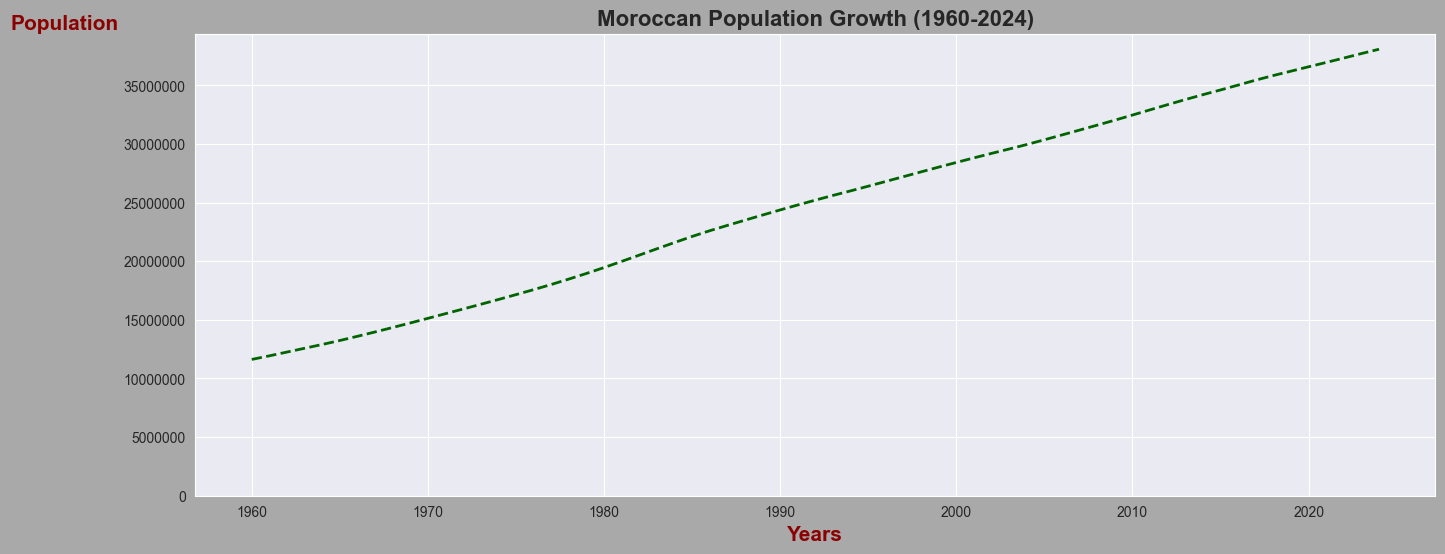

In [25]:
plt.figure(figsize=(16, 6))

sns.lineplot(data=df_morocco_years, x='Year', y='Population', linewidth=2, color='DarkGreen',  linestyle='--')
plt.title('Moroccan Population Growth (1960-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Years', fontsize=15, color='DarkRed', fontweight='bold')


plt.gcf().set_facecolor('Darkgray')
sns.set_style('darkgrid') 

plt.ylabel('Population',fontweight='bold', fontsize=15, color='DarkRed', rotation=0, loc='top')
plt.ylim(bottom=0)

plt.ticklabel_format(style='plain', axis='y')  

plt.show()

In [26]:
ma_ratio=df_morocco_years['Population'].iloc[64]/df_morocco_years['Population'].iloc[0]
print(f"From 1960 to 2024 the moroccan population grew by {ma_ratio:.2f} times")

From 1960 to 2024 the moroccan population grew by 3.28 times


In [27]:
G_ratio=df_world_years['Global Population'].iloc[64]/df_world_years['Global Population'].iloc[0]
print(f"From 1960 to 2024 the global population grew by {G_ratio:.2f} times")

From 1960 to 2024 the global population grew by 2.69 times


In [28]:
import sys
import os

sys.path.append(os.path.abspath("../../src"))

In [29]:
import utils

In [30]:
df_test=utils.prepare_for_visual(df_countries,'Liberia','p')

In [31]:
df_test

,Year,Liberia's Population
0,1960,"1,139,522"
1,1961,"1,167,717"
2,1962,"1,197,039"
3,1963,"1,227,414"
4,1964,"1,258,745"
...,...,...
60,2020,"5,149,463"
61,2021,"5,259,323"
62,2022,"5,373,294"
63,2023,"5,493,031"


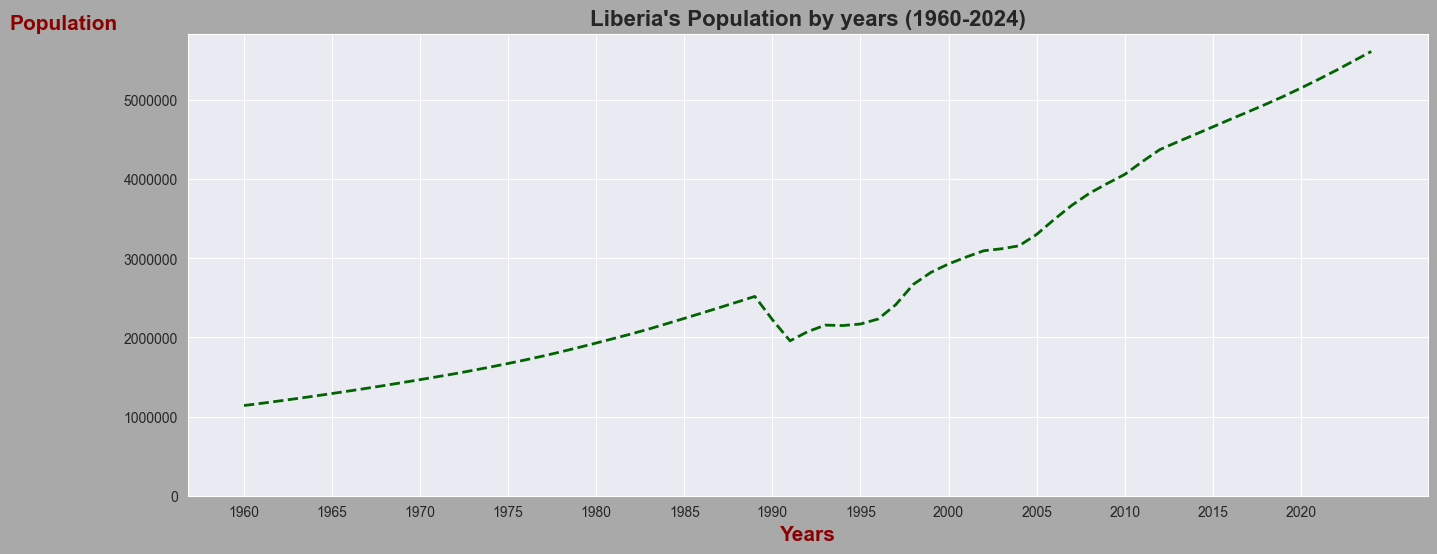

In [32]:
utils.visualize(df_test,'Liberia','p', start_from_zero=True, plot_title='Liberia')